## SSL Demos (Rotation + SimCLR) with Tiny CNN + Nearest Neighbors

This notebook:
- Uses **CIFAR-10** (not STL-10)
- Uses a **tiny CNN encoder** (not ResNet-18)
- Adds **lots of prints + visuals** to explain what’s happening
- Shows **Nearest Neighbors (cosine similarity)** on test embeddings to compare representation quality

We will train:
1) Rotation self-supervised learning (predict 0/90/180/270)
2) SimCLR-style contrastive learning (InfoNCE / NT-Xent only)

Then we compare nearest neighbors for:
- Rotation encoder
- SimCLR encoder

In [2]:
import random, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

seed = 42
random.seed(seed); np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

device: cuda


## Load dataset (CIFAR-10)

CIFAR-10 images are **32×32**, so if you display them large, they will look pixelated.
That’s normal.

We keep a **raw PIL dataset** for clean visualization, and a **tensor+normalized dataset** for embedding extraction.

In [4]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

In [6]:
data_dir = './data'

In [7]:
#CELL 2: Load CIFAR-10 (raw for display + tensor versions for training)
train_raw = torchvision.datasets.CIFAR10(data_dir, train=True, download=True, transform=None)
test_raw  = torchvision.datasets.CIFAR10(data_dir, train=False, download=True, transform=None)

100%|██████████| 170M/170M [27:01<00:00, 105kB/s]


In [8]:
mean = (0.4914, 0.4822, 0.4465)
std  = (0.2470, 0.2435, 0.2616)

In [9]:
# tensors for evaluation embeddings (no heavy augmentation, just normalize)
test_tf = T.Compose(
    [
        T.ToTensor(),
        T.Normalize(mean, std)
    ]
)

In [10]:
test_tensor = torchvision.datasets.CIFAR10(data_dir, train=False, download=False, transform=test_tf)

In [11]:
print("Train size:", len(train_raw), "Test size:", len(test_raw))

Train size: 50000 Test size: 10000


## Visualization helpers (sharp / crisp)

We display images with:
- `interpolation="nearest"` (no smoothing)
- `resize(..., resample=0)` to scale up with nearest-neighbor pixels

This avoids the “blurry” look.

In [13]:
# Visualization helpers (sharp, not blurry)
def show_pil_row(pil_images, titles=None, figsize=(12,3)):
    fig, axes = plt.subplots(1, len(pil_images), figsize=figsize)
    if len(pil_images) == 1:
        axes = [axes]
    for i, ax in enumerate(axes):
        ax.imshow(pil_images[i], interpolation="nearest")  # crisp pixels
        ax.axis("off")
        if titles is not None:
            ax.set_title(titles[i])
    plt.show()

In [14]:
def tensor_to_display_img(x):
    # x: normalized tensor [3,H,W]
    x = x.detach().cpu().clone()
    for c in range(3):
        x[c] = x[c] * std[c] + mean[c]
    x = x.clamp(0,1)
    return x.permute(1,2,0).numpy()

In [ ]:
def show_tensor_row(tensors, titles=None, figsize=(12,3)):
    fig, axes = plt.subplots(1, len(tensors), figsize=figsize)
    if len(tensors) == 1:
        axes = [axes]
    for i, ax in enumerate(axes):
        ax.imshow(tensor_to_display_img(tensors[i]), interpolation="nearest")
        ax.axis("off")
        if titles is not None:
            ax.set_title(titles[i])
    plt.show()

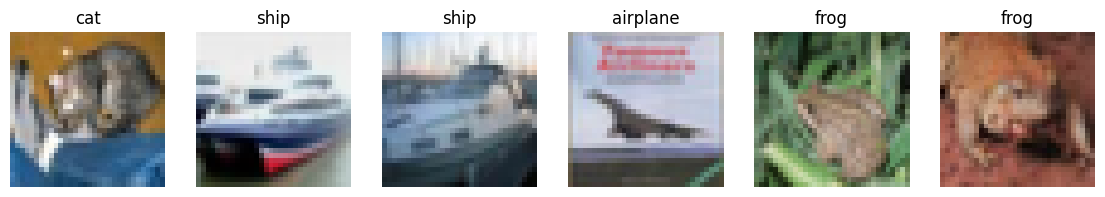

In [15]:
# quick sanity: show a few raw test images (pixelated is normal)
imgs = [test_raw[i][0].resize((128,128), resample=0) for i in range(6)]  # resample=0 => nearest
titles = [classes[test_raw[i][1]] for i in range(6)]
show_pil_row(imgs, titles=titles, figsize=(14,3))

## Tiny CNN encoder (used for both demos)



The encoder outputs an **embedding vector** (e.g., 128-d).

In [16]:
#  CELL 4: Tiny CNN encoder (shared idea, but separate weights per method)
class TinyEncoder(nn.Module):
    def __init__(self, emb_dim=128):
        super().__init__()
        self.conv = nn.Sequential(
            #3 channel RGB -> 32 feature maps
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            #reduce spatial size to 16x16
            nn.MaxPool2d(2),  # 16x16
            #increase channel 32->64
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            #downsample to 8x8
            nn.MaxPool2d(2),  # 8x8
            #to 128 channels
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            #compressing feature maps into single num.
            nn.AdaptiveAvgPool2d((1, 1))     # 1x1
        )
        self.fc = nn.Linear(128, emb_dim)

    def forward(self, x):
        h = self.conv(x).flatten(1)    # [B,128]
        z = self.fc(h)                 # [B,emb_dim]
        return z

print("TinyEncoder ready.")

TinyEncoder ready.


# ROTATION SSL

## Demo 1 — Rotation Self-Supervised Learning

Self-supervised idea:
- Take an image
- Rotate it by **0°, 90°, 180°, 270°**
- The rotation angle becomes a **free label** (no human annotation)

We train:
- encoder + rotation-head (4 classes)

Then we will later use the encoder for embeddings / nearest neighbors.

In [17]:
#augmentation to learn strong visual features instead of memorizing pixels
ssl_tf_rot = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean, std),
])

In [18]:
class RotSSL(Dataset):
    def __init__(self, base, transform):
        self.base = base
        self.transform = transform
    def __len__(self):
        return len(self.base)
    def __getitem__(self, idx):
        img, _ = self.base[idx]             # ignore CIFAR label
        rot_label = random.randint(0, 3)    # 0..3
        img_rot = T.functional.rotate(img, 90 * rot_label)
        x = self.transform(img_rot)
        return x, torch.tensor(rot_label, dtype=torch.long)

In [19]:
# Rotation SSL dataset + visualize rotations clearly
rot_ds = RotSSL(train_raw, ssl_tf_rot)
rot_loader = DataLoader(rot_ds, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)

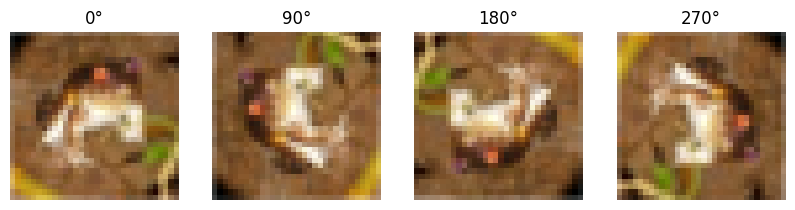

Rotation batch x: torch.Size([128, 3, 32, 32]) Rotation labels r: torch.Size([128])
First 16 rotation labels: [1, 0, 3, 1, 2, 2, 1, 2, 2, 2, 2, 1, 2, 1, 0, 2]


In [20]:
# visualize: same image, 0/90/180/270 in a crisp way
img0, y0 = train_raw[0]
rot_degs = [0, 90, 180, 270]
rot_pils = [T.functional.rotate(img0, d).resize((128,128), resample=0) for d in rot_degs]
rot_titles = [f"{d}°" for d in rot_degs]
show_pil_row(rot_pils, rot_titles, figsize=(10,3))

x, r = next(iter(rot_loader))
print("Rotation batch x:", x.shape, "Rotation labels r:", r.shape)
print("First 16 rotation labels:", r[:16].tolist())

### Rotation model = encoder + rotation head

We do one forward pass and print shapes so students understand what the network outputs.

In [21]:
# Rotation SSL model = encoder + rotation head
encoder_rot = TinyEncoder(emb_dim=128).to(device)
rot_head = nn.Linear(128, 4).to(device)

In [22]:
# print shapes on one forward pass
x, r = next(iter(rot_loader))
x, r = x.to(device), r.to(device)

z = encoder_rot(x)
logits = rot_head(z)

In [23]:
print("x:", x.shape)
print("z (embedding):", z.shape)
print("logits:", logits.shape)
print("Example logits[0]:", logits[0].detach().cpu().numpy())

x: torch.Size([128, 3, 32, 32])
z (embedding): torch.Size([128, 128])
logits: torch.Size([128, 4])
Example logits[0]: [ 0.11397654 -0.01388496  0.11379594 -0.03790177]


### Train Rotation SSL (short run)

This is a demo, so we keep epochs small.
If you want clearer nearest-neighbor results, increase `epochs_rot`.

In [24]:
opt = torch.optim.Adam(list(encoder_rot.parameters()) + list(rot_head.parameters()), lr=3e-4, weight_decay=1e-4)
crit = nn.CrossEntropyLoss()

In [25]:
epochs_rot = 5  # demo: keep short; increase for better features

In [26]:
# Train Rotation SSL (small, explainable training)
for ep in range(1, epochs_rot+1):
    encoder_rot.train(); rot_head.train()
    losses, accs = [], []
    t0 = time.time()

    for step, (x, r) in enumerate(rot_loader):
        x, r = x.to(device), r.to(device)
        z = encoder_rot(x)
        logits = rot_head(z)
        loss = crit(logits, r)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        losses.append(loss.item())
        accs.append((logits.argmax(1) == r).float().mean().item())

        if step % 150 == 0:
            print(f"  step {step:03d} | loss {loss.item():.3f} | batch_acc {accs[-1]:.3f}")

    print(f"[ROT SSL epoch {ep}] mean_loss {np.mean(losses):.3f} | mean_acc {np.mean(accs):.3f} | {time.time()-t0:.1f}s")

print("Rotation SSL training done.")

  step 000 | loss 1.391 | batch_acc 0.242
  step 150 | loss 1.323 | batch_acc 0.367
  step 300 | loss 1.280 | batch_acc 0.336
[ROT SSL epoch 1] mean_loss 1.317 | mean_acc 0.339 | 21.8s
  step 000 | loss 1.271 | batch_acc 0.375
  step 150 | loss 1.224 | batch_acc 0.406
  step 300 | loss 1.151 | batch_acc 0.422
[ROT SSL epoch 2] mean_loss 1.211 | mean_acc 0.413 | 20.1s
  step 000 | loss 1.285 | batch_acc 0.336
  step 150 | loss 1.210 | batch_acc 0.406
  step 300 | loss 1.128 | batch_acc 0.484
[ROT SSL epoch 3] mean_loss 1.174 | mean_acc 0.436 | 20.0s
  step 000 | loss 1.104 | batch_acc 0.523
  step 150 | loss 1.154 | batch_acc 0.383
  step 300 | loss 1.179 | batch_acc 0.461
[ROT SSL epoch 4] mean_loss 1.148 | mean_acc 0.449 | 20.5s
  step 000 | loss 1.108 | batch_acc 0.453
  step 150 | loss 1.099 | batch_acc 0.523
  step 300 | loss 1.159 | batch_acc 0.492
[ROT SSL epoch 5] mean_loss 1.136 | mean_acc 0.458 | 22.3s
Rotation SSL training done.


# SimCLR DEMO (USING InfoNCE)

## Demo 2 — SimCLR (Contrastive learning) with InfoNCE only

Core idea:
- For each image, create **two augmented views** (view1, view2).

-Positive pair = two different views of the same underlying image.
- Encoder should produce similar embeddings for (view1, view2) of the **same** image.
- In a batch, all other images act as **negatives**.

We use NT-Xent / InfoNCE loss:
- pushes **positive pairs closer**
- pushes **negative pairs apart**

In [27]:
aug = T.Compose([
    T.RandomResizedCrop(32, scale=(0.6, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(0.4, 0.4, 0.4, 0.1),
    T.RandomGrayscale(p=0.2),
    T.ToTensor(),
    T.Normalize(mean, std),
])

In [28]:
# SimCLR dataset (two augmented views) + visualize the two views
class TwoViews(Dataset):
    def __init__(self, base, aug):
        self.base = base
        self.aug = aug
    def __len__(self):
        return len(self.base)
    def __getitem__(self, idx):
        img, _ = self.base[idx]
        x1 = self.aug(img)
        x2 = self.aug(img)
        return x1, x2

In [29]:
simclr_ds = TwoViews(train_raw, aug)
simclr_loader = DataLoader(simclr_ds, batch_size=128, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)

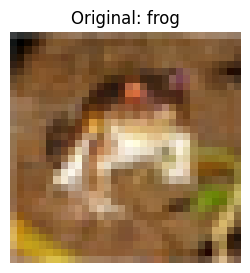

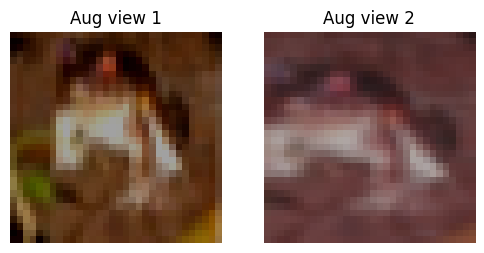

SimCLR batch x1: torch.Size([128, 3, 32, 32]) x2: torch.Size([128, 3, 32, 32])


In [30]:
# visualize: original + two augmented views
img0, y0 = train_raw[0]
v1 = aug(img0)
v2 = aug(img0)
show_pil_row([img0.resize((128,128), resample=0)], [f"Original: {classes[y0]}"], figsize=(3,3))
show_tensor_row([v1, v2], ["Aug view 1", "Aug view 2"], figsize=(6,3))

x1, x2 = next(iter(simclr_loader))
print("SimCLR batch x1:", x1.shape, "x2:", x2.shape)

### SimCLR model = encoder + projection head

- Encoder gives a representation (embedding)
- Projection head maps to a space where contrastive loss is applied

the encoder learns the main image features, and the projection head reshapes those features into a space where the contrastive learning objective can effectively pull similar images together and push different images apart.

In [31]:
# SimCLR model = encoder + projection head
encoder_sim = TinyEncoder(emb_dim=128).to(device)

proj = nn.Sequential(
    nn.Linear(128, 128), nn.ReLU(inplace=True),
    nn.Linear(128, 64)
).to(device)

In [32]:
# show one forward pass shapes
x1, x2 = next(iter(simclr_loader))
x1, x2 = x1.to(device), x2.to(device)

h1 = encoder_sim(x1)
h2 = encoder_sim(x2)
z1 = proj(h1)
z2 = proj(h2)

print("h1/h2 (encoder embeddings):", h1.shape, h2.shape)
print("z1/z2 (projected):", z1.shape, z2.shape)

h1/h2 (encoder embeddings): torch.Size([128, 128]) torch.Size([128, 128])
z1/z2 (projected): torch.Size([128, 64]) torch.Size([128, 64])


### InfoNCE / NT-Xent loss + similarity matrix preview

We print a small corner of the similarity matrix.


- Each row = one anchor sample
- The positive for anchor i is the *matching augmented view*
- All other samples in the batch are negatives

In [33]:
tau = 0.2

In [34]:
#  InfoNCE / NT-Xent loss + show similarity matrix (VERY teachable)
def nt_xent(z1, z2, tau=0.2):
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    B = z1.size(0)

    z = torch.cat([z1, z2], dim=0)         # [2B,D]
    sim = (z @ z.T) / tau                  # [2B,2B]

    # mask diagonal (self similarity)
    eye = torch.eye(2*B, device=z.device, dtype=torch.bool)
    sim = sim.masked_fill(eye, -1e9)

    # positives at offsets ±B
    pos = torch.cat([torch.diag(sim, B), torch.diag(sim, -B)], dim=0)  # [2B]
    denom = torch.logsumexp(sim, dim=1)                                # [2B]
    return (-pos + denom).mean()

In [35]:
# Show similarity matrix snippet for one batch
encoder_sim.eval(); proj.eval()
with torch.no_grad():
    x1, x2 = next(iter(simclr_loader))
    x1, x2 = x1.to(device), x2.to(device)
    z1 = proj(encoder_sim(x1))
    z2 = proj(encoder_sim(x2))
    z1n = F.normalize(z1, dim=1)
    z2n = F.normalize(z2, dim=1)
    Z = torch.cat([z1n, z2n], dim=0)       # [2B,D]
    sim = (Z @ Z.T) / tau                  # [2B,2B]
    print("Sim matrix shape:", sim.shape)
    print("Top-left 8x8 (values):")
    print(sim[:8,:8].detach().cpu().numpy())

    loss_val = nt_xent(z1, z2, tau=tau)
    print("NT-Xent loss (one batch):", float(loss_val.detach().cpu()))

print()
print("Interpretation:")
print("- each row is an anchor")
print("- the matching augmented view is the POSITIVE")
print("- all other images in batch are NEGATIVES")

Sim matrix shape: torch.Size([256, 256])
Top-left 8x8 (values):
[[5.        4.881321  4.707574  4.9931474 4.979389  4.9540625 4.981037
  4.985775 ]
 [4.881321  4.9999995 4.9478254 4.902946  4.9258647 4.9666743 4.920601
  4.9081783]
 [4.707574  4.9478254 4.999999  4.7365613 4.775684  4.8525214 4.770919
  4.7496367]
 [4.9931474 4.902946  4.7365613 4.9999995 4.9948034 4.9744077 4.995016
  4.99685  ]
 [4.979389  4.9258647 4.775684  4.9948034 5.0000005 4.987498  4.9989862
  4.9979806]
 [4.9540625 4.9666743 4.8525214 4.9744077 4.987498  4.9999995 4.9852433
  4.979433 ]
 [4.981037  4.920601  4.770919  4.995016  4.9989862 4.9852433 5.0000005
  4.9990463]
 [4.985775  4.9081783 4.7496367 4.99685   4.9979806 4.979433  4.9990463
  5.       ]]
NT-Xent loss (one batch): 5.52802038192749

Interpretation:
- each row is an anchor
- the matching augmented view is the POSITIVE
- all other images in batch are NEGATIVES


### Train SimCLR (InfoNCE only)

Again: small epochs for demo.
Increase `epochs_sim` for stronger nearest neighbors.

In [37]:
opt = torch.optim.Adam(list(encoder_sim.parameters()) + list(proj.parameters()), lr=3e-4, weight_decay=1e-4)

In [38]:
epochs_sim = 10  # demo short; increase for stronger NN retrieval

In [39]:
#  Train SimCLR (InfoNCE only)
for ep in range(1, epochs_sim+1):
    encoder_sim.train(); proj.train()
    losses = []
    t0 = time.time()

    for step, (x1, x2) in enumerate(simclr_loader):
        x1, x2 = x1.to(device), x2.to(device)
        z1 = proj(encoder_sim(x1))
        z2 = proj(encoder_sim(x2))
        loss = nt_xent(z1, z2, tau=tau)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        losses.append(loss.item())
        if step % 150 == 0:
            print(f"  step {step:03d} | loss {loss.item():.3f}")

    print(f"[SimCLR epoch {ep}] mean_loss {np.mean(losses):.3f} | {time.time()-t0:.1f}s")

print("SimCLR training done.")

  step 000 | loss 5.527
  step 150 | loss 4.102
  step 300 | loss 3.674
[SimCLR epoch 1] mean_loss 4.059 | 88.3s
  step 000 | loss 3.279
  step 150 | loss 3.058
  step 300 | loss 2.902
[SimCLR epoch 2] mean_loss 3.044 | 86.4s
  step 000 | loss 3.016
  step 150 | loss 2.684
  step 300 | loss 2.619
[SimCLR epoch 3] mean_loss 2.753 | 83.6s
  step 000 | loss 2.708
  step 150 | loss 2.616
  step 300 | loss 2.608
[SimCLR epoch 4] mean_loss 2.586 | 83.1s
  step 000 | loss 2.512
  step 150 | loss 2.483
  step 300 | loss 2.441
[SimCLR epoch 5] mean_loss 2.482 | 83.0s
  step 000 | loss 2.372
  step 150 | loss 2.436
  step 300 | loss 2.387
[SimCLR epoch 6] mean_loss 2.392 | 84.0s
  step 000 | loss 2.455
  step 150 | loss 2.342
  step 300 | loss 2.323
[SimCLR epoch 7] mean_loss 2.333 | 83.1s
  step 000 | loss 2.307
  step 150 | loss 2.262
  step 300 | loss 2.236
[SimCLR epoch 8] mean_loss 2.279 | 82.8s
  step 000 | loss 2.191
  step 150 | loss 2.206
  step 300 | loss 2.240
[SimCLR epoch 9] mean_lo

#NEAREST NEIGHBOR COMPRAISON

## Nearest Neighbors on test embeddings (cosine similarity)

We compute embeddings for the CIFAR-10 test set and compare:
- Rotation encoder neighbors
- SimCLR encoder neighbors

We use cosine similarity in embedding space:
- Normalize embeddings
- Similarity = dot product

In [40]:
test_loader = DataLoader(test_tensor, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

In [41]:
# Compute test embeddings for each encoder
@torch.no_grad()
def compute_embeddings(encoder, loader):
    encoder.eval()
    embs = []
    for x, _ in loader:
        x = x.to(device)
        z = encoder(x)                  # [B,128]
        z = F.normalize(z, dim=1)
        embs.append(z.cpu())
    return torch.cat(embs, dim=0)       # [N,128]

In [42]:
emb_rot = compute_embeddings(encoder_rot, test_loader)
emb_sim = compute_embeddings(encoder_sim, test_loader)

print("emb_rot:", emb_rot.shape, "emb_sim:", emb_sim.shape)

emb_rot: torch.Size([10000, 128]) emb_sim: torch.Size([10000, 128])


In [43]:
# Also collect test labels for display
test_labels = [test_raw[i][1] for i in range(len(test_raw))]

### Retrieve top-5 neighbors for the same query images

Important for fairness:
- we use the SAME query indices for each encoder
- we show: Query + 5 nearest neighbors + class labels + cosine similarity

In [44]:
#  Nearest neighbor retrieval + visualization
# We'll use cosine similarity: sim(a,b) = a dot b (since normalized)

def show_neighbors_for_encoder(embeddings, query_indices, title):
    print("\n", "="*70)
    print(title)
    print("="*70)

    # precompute similarity matrix rows only for queries (fast enough for CIFAR test=10k)
    E = embeddings  # [N,D], already normalized on CPU

    for qi in query_indices:
        q_img, q_y = test_raw[qi]
        q_emb = E[qi]                   # [D]
        sims = (E @ q_emb)              # [N]
        topk = torch.topk(sims, k=6).indices.tolist()  # includes self usually
        # remove self if present
        topk = [j for j in topk if j != qi][:5]

        # build display row: query + 5 neighbors
        disp_imgs = [q_img.resize((128,128), resample=0)]
        disp_titles = [f"QUERY\nidx={qi}\n{classes[q_y]}"]

        for j in topk:
            imgj, yj = test_raw[j]
            disp_imgs.append(imgj.resize((128,128), resample=0))
            disp_titles.append(f"NN idx={j}\n{classes[yj]}\ncos={float(sims[j]):.2f}")

        show_pil_row(disp_imgs, disp_titles, figsize=(16,3))

Using query indices: [3, 25, 100]

Rotation-SSL Encoder Nearest Neighbors (Cosine)


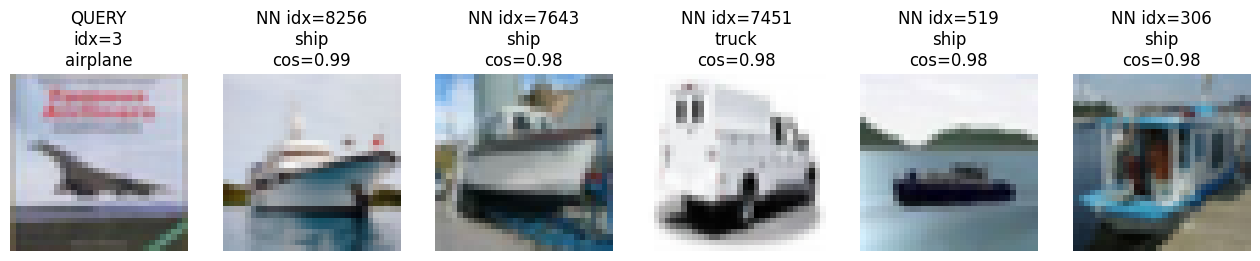

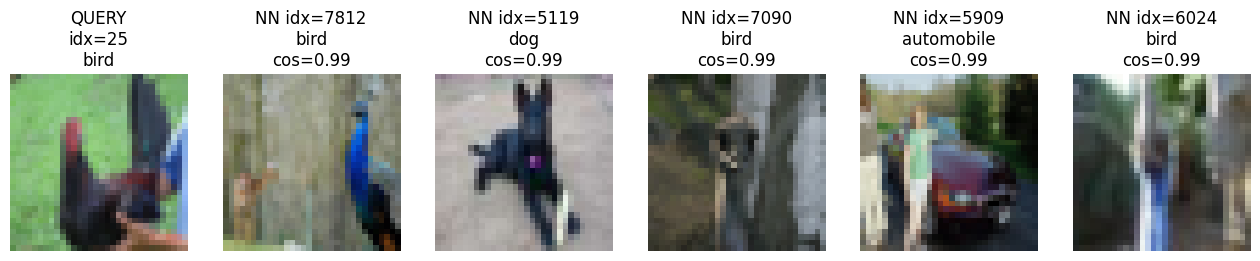

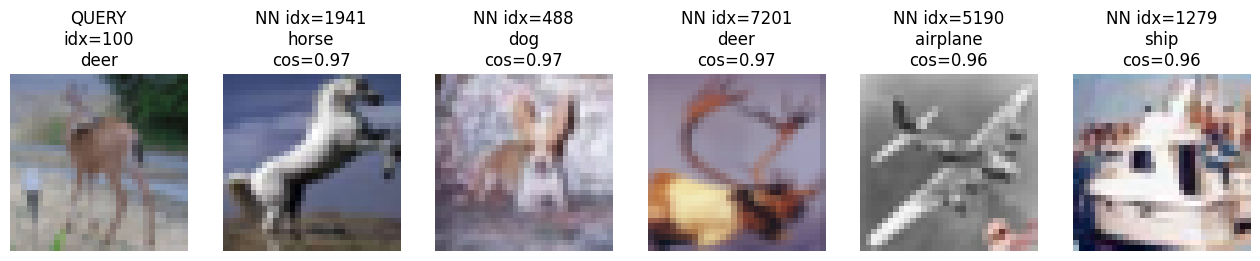


SimCLR Encoder Nearest Neighbors (Cosine)


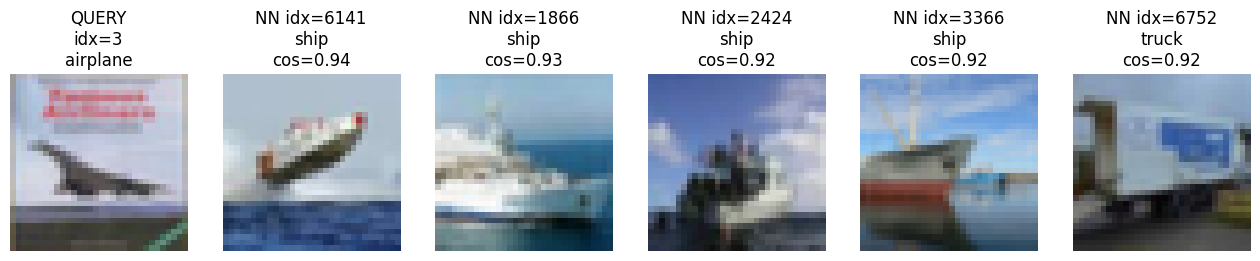

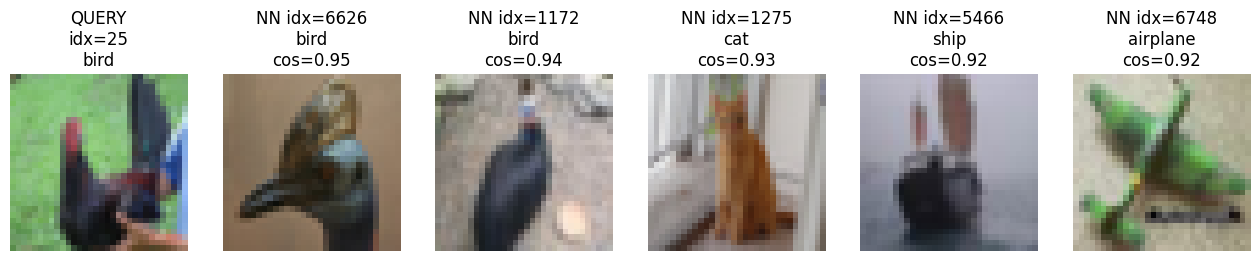

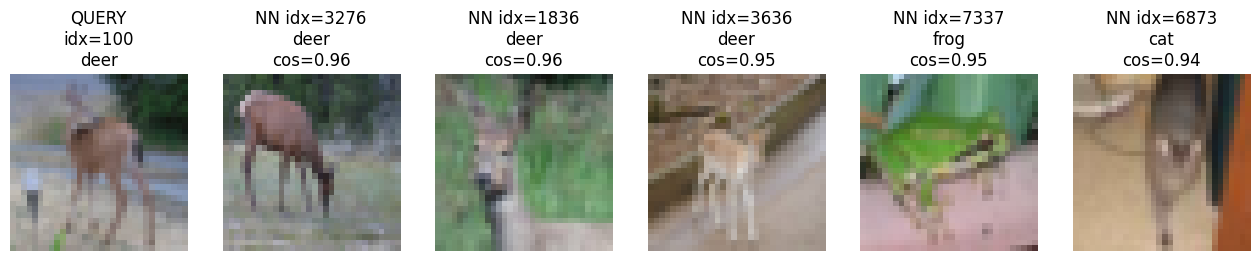

In [45]:
# Choose SAME queries for both encoders (important for fair comparison)
query_indices = [3, 25, 100]  # change these if you want other examples
print("Using query indices:", query_indices)

show_neighbors_for_encoder(emb_rot, query_indices, "Rotation-SSL Encoder Nearest Neighbors (Cosine)")
show_neighbors_for_encoder(emb_sim, query_indices, "SimCLR Encoder Nearest Neighbors (Cosine)")